In [11]:
import parselmouth
import matplotlib.pyplot as plt

# 注意：请确保你已经把录音文件拖进了左侧的文件夹，并把下方的文件名改对
audio_file = "Tky-Recording-1.wav" 

try:
    snd = parselmouth.Sound(audio_file)
    pitch = snd.to_pitch()
    
    # 开始绘图
    plt.figure(figsize=(10, 4))
    plt.plot(pitch.xs(), pitch.selected_array['frequency'], 'ro', markersize=2)
    plt.ylim(0, 500)
    plt.ylabel("Frequency (Hz)")
    plt.title("Azerbaijani Word Stress Analysis")
    plt.show()
    print("图表生成成功！")
except Exception as e:
    print(f"出错啦: {e}。请检查文件名是否正确，或者是否已将录音拖入左侧列表。")

出错啦: Cannot open file “/Users/tukaiyang/Desktop/Azerbaijani-Prosody-Research/Tky-Recording-1.wav”.
Sound not read from sound file “/Users/tukaiyang/Desktop/Azerbaijani-Prosody-Research/Tky-Recording-1.wav”.。请检查文件名是否正确，或者是否已将录音拖入左侧列表。


In [12]:
import parselmouth
import matplotlib.pyplot as plt

# 确保文件名一致
audio_file = "Tky-Recording-1.wav"

try:
    snd = parselmouth.Sound(audio_file)
    pitch = snd.to_pitch()
    
    plt.figure(figsize=(10, 5))
    
    # 绘图：用红色的点表示每一个 Pitch 采样
    plt.plot(pitch.xs(), pitch.selected_array['frequency'], 'ro', markersize=4, label="Pitch (F0)")
    
    # --- 核心：填入你在 Praat 里测得的精准时间戳 ---
    plt.xlim(1.467530, 1.912320)  
    
    # 将纵坐标固定在语音常见的范围，让曲线更饱满
    plt.ylim(50, 300)     
    
    plt.ylabel("Frequency (Hz)")
    plt.xlabel("Time (s)")
    plt.title("Acoustic Analysis: 'gözəl' (Target Segment)")
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.show()
    
    print(f"成功截取目标词！分析区间：{1.467530}s 至 {1.912320}s")
except Exception as e:
    print(f"运行出错: {e}")

运行出错: Cannot open file “/Users/tukaiyang/Desktop/Azerbaijani-Prosody-Research/Tky-Recording-1.wav”.
Sound not read from sound file “/Users/tukaiyang/Desktop/Azerbaijani-Prosody-Research/Tky-Recording-1.wav”.


In [13]:
import os
import parselmouth
import pandas as pd

# 1. Define the academic word list from your research paper mapping (1-20)
WORD_LIST = {
    "01": "gözəl", "02": "təmiz", "03": "dərin", "04": "qalın", "05": "çürük",
    "06": "soyuq", "07": "geniş", "08": "yaman", "09": "sərin", "10": "dayaz",
    "11": "çətin", "12": "yaşıl", "13": "alçaq", "14": "qısa", "15": "dolu",
    "16": "qara", "17": "yazıq", "18": "yalın", "19": "çevik", "20": "soluq"
}

def scan_speech_corpus(base_dir, group_label):
    """
    Scans the specific audio directory, validates filenames, maps them to the word list,
    and extracts phonetic metadata using Parselmouth.
    """
    report_data = []
    if not os.path.exists(base_dir):
        print(f"Directory not found: {base_dir}")
        return report_data
        
    print(f"Scanning {group_label} group in '{base_dir}'...")
    
    # Loop through all files
    for filename in os.listdir(base_dir):
        if filename.endswith(".wav"):
            file_path = os.path.join(base_dir, filename)
            
            # Parse the 3-tier naming convention (e.g., L1_01_01.wav)
            name_parts = filename.replace(".wav", "").split("_")
            
            if len(name_parts) == 3:
                group, subject_id, word_id = name_parts
                
                # Map the sentence/word ID to the actual Azerbaijani word
                target_word = WORD_LIST.get(word_id, "Unknown Word")
                
                try:
                    # Sound analysis using Parselmouth
                    snd = parselmouth.Sound(file_path)
                    duration = snd.get_total_duration()
                    sampling_rate = snd.sampling_frequency
                    
                    report_data.append({
                        "Group": group,
                        "Subject": f"Subject_{subject_id}",
                        "Word ID": word_id,
                        "Target Word": target_word,
                        "Duration (s)": round(duration, 3),
                        "Sampling Rate (Hz)": sampling_rate,
                        "Status": "OK"
                    })
                except Exception as e:
                    print(f"⚠️ Error reading file {filename}: {e}")
            else:
                print(f"❌ Warning: Filename '{filename}' does not follow the 3-tier convention!")
                
    return report_data

# =========================================================
# EXECUTE CORPUS AUDIT
# =========================================================
learner_path = "/audio/learner/"
native_path = "/audio/native/"

all_results = []
all_results.extend(scan_speech_corpus(learner_path, "L2 Learners"))
all_results.extend(scan_speech_corpus(native_path, "L1 Native Speakers"))

# Convert to pandas DataFrame for premium visual presentation
if all_results:
    corpus_df = pd.DataFrame(all_results)
    # Sort for beautiful structure
    corpus_df = corpus_df.sort_values(by=["Group", "Subject", "Word ID"])
    
    print("\n" + "="*25 + " SPEECH CORPUS AUDIT REPORT " + "="*25)
    print(f"Total valid speech samples found: {len(corpus_df)} / 200")
    print("="*76)
    print(corpus_df.to_string(index=False))
else:
    print("No valid audio files detected. Please verify your file placement.")

Directory not found: /audio/learner/
Directory not found: /audio/native/
No valid audio files detected. Please verify your file placement.


In [14]:
import os
import parselmouth
import pandas as pd

# 1. Define the academic word list from your research paper mapping (1-20)
WORD_LIST = {
    "01": "gözəl", "02": "təmiz", "03": "dərin", "04": "qalın", "05": "çürük",
    "06": "soyuq", "07": "geniş", "08": "yaman", "09": "sərin", "10": "dayaz",
    "11": "çətin", "12": "yaşıl", "13": "alçaq", "14": "qısa", "15": "dolu",
    "16": "qara", "17": "yazıq", "18": "yalın", "19": "çevik", "20": "soluq"
}

def scan_speech_corpus(base_dir, group_label):
    """
    Scans the specific audio directory, validates filenames, maps them to the word list,
    and extracts phonetic metadata using Parselmouth.
    """
    report_data = []
    if not os.path.exists(base_dir):
        print(f"Directory not found: {base_dir}")
        return report_data
        
    print(f"Scanning {group_label} group in '{base_dir}'...")
    
    # Loop through all files
    for filename in os.listdir(base_dir):
        if filename.endswith(".wav"):
            file_path = os.path.join(base_dir, filename)
            
            # Parse the 3-tier naming convention (e.g., L1_01_01.wav)
            name_parts = filename.replace(".wav", "").split("_")
            
            if len(name_parts) == 3:
                group, subject_id, word_id = name_parts
                
                # Map the sentence/word ID to the actual Azerbaijani word
                target_word = WORD_LIST.get(word_id, "Unknown Word")
                
                try:
                    # Sound analysis using Parselmouth
                    snd = parselmouth.Sound(file_path)
                    duration = snd.get_total_duration()
                    sampling_rate = snd.sampling_frequency
                    
                    report_data.append({
                        "Group": group,
                        "Subject": f"Subject_{subject_id}",
                        "Word ID": word_id,
                        "Target Word": target_word,
                        "Duration (s)": round(duration, 3),
                        "Sampling Rate (Hz)": sampling_rate,
                        "Status": "OK"
                    })
                except Exception as e:
                    print(f"⚠️ Error reading file {filename}: {e}")
            else:
                print(f"❌ Warning: Filename '{filename}' does not follow the 3-tier convention!")
                
    return report_data

# =========================================================
# EXECUTE CORPUS AUDIT (PERFECTLY ALIGNED WITH YOUR PATHS)
# =========================================================
# Removed '../' and updated with your exact folder names
learner_path = "audio/L2_learners_Chinese/"
native_path = "audio/Native_Speakers/"

all_results = []
all_results.extend(scan_speech_corpus(learner_path, "L2 Learners"))
all_results.extend(scan_speech_corpus(native_path, "L1 Native Speakers"))

# Convert to pandas DataFrame for premium visual presentation
if all_results:
    corpus_df = pd.DataFrame(all_results)
    # Sort for beautiful structure
    corpus_df = corpus_df.sort_values(by=["Group", "Subject", "Word ID"])
    
    print("\n" + "="*25 + " SPEECH CORPUS AUDIT REPORT " + "="*25)
    print(f"Total valid speech samples found: {len(corpus_df)} / 200")
    print("="*76)
    print(corpus_df.to_string(index=False))
else:
    print("No valid audio files detected. Please verify your file placement.")

Directory not found: audio/L2_learners_Chinese/
Directory not found: audio/Native_Speakers/
No valid audio files detected. Please verify your file placement.


In [15]:
# =========================================================
# FIND MISSING AUDIO FILES
# =========================================================

print("=== MISSING FILES DETECTED ===")
missing_count = 0

# Loop through both groups
for group_prefix, group_dir in [("L1", "audio/Native_Speakers/"), ("L2", "audio/L2_learners_Chinese/")]:
    # Loop through all 5 subjects
    for sub in range(1, 6):
        subject_id = f"{sub:02d}"
        
        # Loop through all 20 target words
        for word_id, word_name in WORD_LIST.items():
            # Construct the file name that SHOULD exist
            expected_filename = f"{group_prefix}_{subject_id}_{word_id}.wav"
            expected_path = os.path.join(group_dir, expected_filename)
            
            # Check if it exists
            if not os.path.exists(expected_path):
                missing_count += 1
                print(f"❌ Missing [{missing_count}]: {expected_filename} (Subject {subject_id} | Word: '{word_name}')")

if missing_count == 0:
    print("🎉 Amazing! No missing files found. All 200 items are present!")
else:
    print(f"\nTotal Missing Files: {missing_count}")

=== MISSING FILES DETECTED ===
❌ Missing [1]: L1_01_01.wav (Subject 01 | Word: 'gözəl')
❌ Missing [2]: L1_01_02.wav (Subject 01 | Word: 'təmiz')
❌ Missing [3]: L1_01_03.wav (Subject 01 | Word: 'dərin')
❌ Missing [4]: L1_01_04.wav (Subject 01 | Word: 'qalın')
❌ Missing [5]: L1_01_05.wav (Subject 01 | Word: 'çürük')
❌ Missing [6]: L1_01_06.wav (Subject 01 | Word: 'soyuq')
❌ Missing [7]: L1_01_07.wav (Subject 01 | Word: 'geniş')
❌ Missing [8]: L1_01_08.wav (Subject 01 | Word: 'yaman')
❌ Missing [9]: L1_01_09.wav (Subject 01 | Word: 'sərin')
❌ Missing [10]: L1_01_10.wav (Subject 01 | Word: 'dayaz')
❌ Missing [11]: L1_01_11.wav (Subject 01 | Word: 'çətin')
❌ Missing [12]: L1_01_12.wav (Subject 01 | Word: 'yaşıl')
❌ Missing [13]: L1_01_13.wav (Subject 01 | Word: 'alçaq')
❌ Missing [14]: L1_01_14.wav (Subject 01 | Word: 'qısa')
❌ Missing [15]: L1_01_15.wav (Subject 01 | Word: 'dolu')
❌ Missing [16]: L1_01_16.wav (Subject 01 | Word: 'qara')
❌ Missing [17]: L1_01_17.wav (Subject 01 | Word: 'yaz

In [16]:
import os
import math
import tgt
import parselmouth
import pandas as pd

def extract_academic_parameters(wav_path, tg_path):
    """
    Extracts acoustic metrics strictly following the operational definitions
    in Section 4.4 of the thesis: Syllabic Duration, Mean/Max Intensity, 
    and F0 converted to Semitones (St).
    """
    if not os.path.exists(tg_path):
        return None
        
    try:
        # Load the annotated Praat TextGrid file
        tg = tgt.io.read_textgrid(tg_path, encoding='utf-8')
        
        # Load the raw audio file via Parselmouth for Digital Signal Processing (DSP)
        sound = parselmouth.Sound(wav_path)
        pitch = sound.to_pitch()
        intensity = sound.to_intensity()
        
        # Fetch the predefined 'syllable' tier for core duration and prosodic analysis
        syllable_tier = tg.get_tier_by_name('syllable')
        
        # Filter out empty intervals to capture only valid target syllables (S1 and S2)
        syllables = [inv for inv in syllable_tier if inv.text.strip()]
        
        if len(syllables) < 2:
            return None
            
        data_row = {}
        
        # Iterating through Syllable 1 (Non-stressed) and Syllable 2 (Final-stressed)
        for idx, syl in enumerate(syllables[:2], start=1):
            label = syl.text
            start = syl.start_time
            end = syl.end_time
            
            # Metric 1: Total temporal length of the entire syllable (converted to milliseconds)
            duration_ms = (end - start) * 1000 
            
            # Metric 2: Extract Mean and Maximum Intensity within the segmented boundaries
            mean_intensity = parselmouth.praat.call(intensity, "Get mean...", start, end, "energy")
            max_intensity = parselmouth.praat.call(intensity, "Get maximum...", start, end, "Parabolic")
            
            # Metric 3: Extract Mean F0 (Hz) and convert to Semitones (St) relative to 100 Hz baseline
            mean_f0_hz = parselmouth.praat.call(pitch, "Get mean...", start, end, "Hertz")
            
            mean_f0_st = None
            if not pd.isna(mean_f0_hz) and mean_f0_hz > 0:
                # Operational Formula: St = 12 * log2(Hz / 100)
                mean_f0_st = 12 * math.log2(mean_f0_hz / 100)
                
            # Populate data structure with standardized linguistic column headers
            data_row[f"S{idx} Label"] = label
            data_row[f"S{idx} Duration (ms)"] = round(duration_ms, 2)
            data_row[f"S{idx} Mean Intensity (dB)"] = round(mean_intensity, 2)
            data_row[f"S{idx} Max Intensity (dB)"] = round(max_intensity, 2)
            data_row[f"S{idx} Mean F0 (Hz)"] = round(mean_f0_hz, 2) if not pd.isna(mean_f0_hz) else None
            data_row[f"S{idx} Mean F0 (St)"] = round(mean_f0_st, 2) if mean_f0_st else None

        # --- Automated Correlate Analysis as specified in Thesis Section 4.4 ---
        # Requirement 2: Calculate the relative intensity difference (S2 - S1)
        data_row["Intensity Diff (S2-S1 dB)"] = round(
            data_row["S2 Mean Intensity (dB)"] - data_row["S1 Mean Intensity (dB)"], 2
        )
        
        # Requirement 1: Calculate the duration ratio for prosodic final lengthening evaluation
        data_row["Duration Ratio (S2/S1)"] = round(
            data_row["S2 Duration (ms)"] / data_row["S1 Duration (ms)"], 2
        )
        
        return data_row
        
    except Exception as e:
        print(f"⚠️ Error processing {os.path.basename(wav_path)}: {e}")
        return None

# Initialize the acoustic core engine
print("✅ Acoustic extraction engine successfully initialized with full English documentation.")

✅ Acoustic extraction engine successfully initialized with full English documentation.


In [17]:
import os
from scipy.io import wavfile

# 1. Specify the relative path to the audio directory
audio_dir = 'audio/'

print("🚀 Starting batch conversion to mono...")
converted_count = 0

# 2. Iterate through all WAV files in the directory
for filename in os.listdir(audio_dir):
    if filename.endswith('.wav') or filename.endswith('.WAV'):
        filepath = os.path.join(audio_dir, filename)
        
        # Read the sample rate and audio data
        sample_rate, data = wavfile.read(filepath)
        
        # Check if the audio is stereo (2 channels)
        if len(data.shape) > 1 and data.shape[1] == 2:
            # Extract the left channel (Channel 1) to convert to mono
            mono_data = data[:, 0]
            
            # Overwrite the original file to keep filenames perfectly aligned with TextGrids
            wavfile.write(filepath, sample_rate, mono_data)
            print(f"✅ Successfully converted: {filename} -> Mono")
            converted_count += 1

print(f"🎉 Done! Processed {converted_count} audio files. All files in '{audio_dir}' are now standardized to mono!")

🚀 Starting batch conversion to mono...
🎉 Done! Processed 0 audio files. All files in 'audio/' are now standardized to mono!


In [18]:
import os
from scipy.io import wavfile

# 1. Specify the relative path to the root audio directory
audio_dir = 'audio/'

print("🚀 Starting recursive batch conversion to mono...")
converted_count = 0

# 2. Use os.walk to recursively search through all nested subdirectories
for root, dirs, files in os.walk(audio_dir):
    for filename in files:
        if filename.endswith('.wav') or filename.endswith('.WAV'):
            filepath = os.path.join(root, filename)
            
            try:
                # Read the sample rate and audio data
                sample_rate, data = wavfile.read(filepath)
                
                # Check if the audio is stereo (2 channels)
                if len(data.shape) > 1 and data.shape[1] == 2:
                    # Extract the left channel (Channel 1) to convert to mono
                    mono_data = data[:, 0]
                    
                    # Overwrite the original file to keep filenames perfectly aligned with TextGrids
                    wavfile.write(filepath, sample_rate, mono_data)
                    
                    # Get the relative path for a cleaner print log
                    display_path = os.path.relpath(filepath, audio_dir)
                    print(f"✅ Successfully converted: {display_path} -> Mono")
                    converted_count += 1
            except Exception as e:
                print(f"❌ Error processing {filename}: {e}")

print(f"\n🎉 Done! Processed {converted_count} audio files across all subdirectories.")
print(f"All nested files in '{audio_dir}' are now standardized to mono!")

🚀 Starting recursive batch conversion to mono...

🎉 Done! Processed 0 audio files across all subdirectories.
All nested files in 'audio/' are now standardized to mono!


In [19]:
from pathlib import Path

# 根目录 Path（会自动遍历内部的所有子文件夹）
textgrid_dir = Path("Textgrid")

# 层名映射表：旧层名 -> 新层名
tier_replacements = {
    '"Az,"': '"Az"',
    '"Ws,"': '"Ws"',
    '"Syl,"': '"Syl"',
    '"Vow,"': '"Vow"',
}

modified_count = 0

for tg_path in textgrid_dir.rglob("*.[tT][eE][xX][tT][gG][rR][iI][dD]"):
    # 兼容 UTF-8 与 UTF-16 编码（Praat 常用编码）
    try:
        content = tg_path.read_text(encoding="utf-8")
        encoding_used = "utf-8"
    except UnicodeDecodeError:
        content = tg_path.read_text(encoding="utf-16")
        encoding_used = "utf-16"

    new_content = content
    for old_name, new_name in tier_replacements.items():
        new_content = new_content.replace(old_name, new_name)

    # 如果有修改，则覆盖写入
    if new_content != content:
        tg_path.write_text(new_content, encoding=encoding_used)
        print(f"✅ 已修正层名: {tg_path.relative_to(textgrid_dir)}")
        modified_count += 1

print(f"\n🎉 处理完成！共修正了 {modified_count} 个 TextGrid 文件。")

✅ 已修正层名: L2_01_Textgrid的副本/L2_01_02.TextGrid

🎉 处理完成！共修正了 1 个 TextGrid 文件。


In [20]:
import re
from pathlib import Path

textgrid_dir = Path("Textgrid")

# 正则匹配 Az, Ws, Syl, Vow 后面紧跟的逗号及任意空格
# 比如 "Az,"、"Az, "、"Az ," 都会被统一精准修正为 "Az"
pattern = re.compile(r'\b(Az|Ws|Syl|Vow)\s*,\s*')

modified_count = 0
total_files = 0

for tg_path in textgrid_dir.rglob("*.[tT][eE][xX][tT][gG][rR][iI][dD]"):
    total_files += 1
    
    # 兼容 UTF-8 和 UTF-16 编码读取
    try:
        content = tg_path.read_text(encoding="utf-8")
        encoding_used = "utf-8"
    except UnicodeDecodeError:
        content = tg_path.read_text(encoding="utf-16")
        encoding_used = "utf-16"

    # 正则替换并统计替换次数
    new_content, substitute_count = pattern.subn(r'\1', content)

    # 只要产生过替换就覆盖保存
    if substitute_count > 0:
        tg_path.write_text(new_content, encoding=encoding_used)
        print(f"✅ 修正了 {substitute_count} 处层名: {tg_path.relative_to(textgrid_dir)}")
        modified_count += 1

print(f"\n🎉 扫描完毕！共检查了 {total_files} 个文件，成功修正了 {modified_count} 个 TextGrid 文件。")


🎉 扫描完毕！共检查了 198 个文件，成功修正了 0 个 TextGrid 文件。


In [21]:
from pathlib import Path

# 设置两个主文件夹路径
audio_dir = Path("audio")
textgrid_dir = Path("Textgrid")

# 提取所有 .wav 和 .TextGrid 的主文件名（忽略后缀和大小写）
audio_files = {f.stem.lower(): f for f in audio_dir.rglob("*.wav")}
tg_files = {f.stem.lower(): f for f in textgrid_dir.rglob("*.[tT][eE][xX][tT][gG][rR][iI][dD]")}

print(f"📁 统计结果：")
print(f"  - 音频文件 (.wav) 总数: {len(audio_files)}")
print(f"  - 标注文件 (.TextGrid) 总数: {len(tg_files)}")
print("=" * 60)

# 找出有音频，但没有对应 TextGrid 的文件
missing_tg = set(audio_files.keys()) - set(tg_files.keys())

if missing_tg:
    print(f"❌ 找到以下 {len(missing_tg)} 个音频文件缺失对应的 TextGrid 文件：\n")
    for stem in sorted(missing_tg):
        # 打印相对路径，方便你准确定位到具体子文件夹
        print(f"  📌 {audio_files[stem].relative_to(audio_dir)}")
else:
    print("✅ 所有音频文件都有对应的 TextGrid！")

print("=" * 60)

# 备查：是否有多余或文件名拼错对不上的 TextGrid
missing_audio = set(tg_files.keys()) - set(audio_files.keys())
if missing_audio:
    print(f"⚠️ 另有 {len(missing_audio)} 个 TextGrid 文件找不到对应的 .wav 音频（可能是文件名拼写有误）：\n")
    for stem in sorted(missing_audio):
        print(f"  🔍 {tg_files[stem].relative_to(textgrid_dir)}")

📁 统计结果：
  - 音频文件 (.wav) 总数: 200
  - 标注文件 (.TextGrid) 总数: 198
❌ 找到以下 2 个音频文件缺失对应的 TextGrid 文件：

  📌 母语组的副本/L1_04/L1_04_08.wav
  📌 学习组的副本/L2_01/L2_01_01.wav


In [22]:
from pathlib import Path

# 设置两个主文件夹路径
audio_dir = Path("audio")
textgrid_dir = Path("Textgrid")

# 提取所有 .wav 和 .TextGrid 的主文件名（忽略后缀和大小写）
audio_files = {f.stem.lower(): f for f in audio_dir.rglob("*.wav")}
tg_files = {f.stem.lower(): f for f in textgrid_dir.rglob("*.[tT][eE][xX][tT][gG][rR][iI][dD]")}

print(f"📁 统计结果：")
print(f"  - 音频文件 (.wav) 总数: {len(audio_files)}")
print(f"  - 标注文件 (.TextGrid) 总数: {len(tg_files)}")
print("=" * 60)

# 找出有音频，但没有对应 TextGrid 的文件
missing_tg = set(audio_files.keys()) - set(tg_files.keys())

if missing_tg:
    print(f"❌ 找到以下 {len(missing_tg)} 个音频文件缺失对应的 TextGrid 文件：\n")
    for stem in sorted(missing_tg):
        # 打印相对路径，方便你准确定位到具体子文件夹
        print(f"  📌 {audio_files[stem].relative_to(audio_dir)}")
else:
    print("✅ 所有音频文件都有对应的 TextGrid！")

print("=" * 60)

# 备查：是否有多余或文件名拼错对不上的 TextGrid
missing_audio = set(tg_files.keys()) - set(audio_files.keys())
if missing_audio:
    print(f"⚠️ 另有 {len(missing_audio)} 个 TextGrid 文件找不到对应的 .wav 音频（可能是文件名拼写有误）：\n")
    for stem in sorted(missing_audio):
        print(f"  🔍 {tg_files[stem].relative_to(textgrid_dir)}")

📁 统计结果：
  - 音频文件 (.wav) 总数: 200
  - 标注文件 (.TextGrid) 总数: 200
✅ 所有音频文件都有对应的 TextGrid！


In [23]:
from pathlib import Path

# 根目录 Path（会自动遍历内部的所有子文件夹）
textgrid_dir = Path("Textgrid")

# 层名映射表：旧层名 -> 新层名
tier_replacements = {
    '"Az,"': '"Az"',
    '"Ws,"': '"Ws"',
    '"Syl,"': '"Syl"',
    '"Vow,"': '"Vow"',
}

modified_count = 0

for tg_path in textgrid_dir.rglob("*.[tT][eE][xX][tT][gG][rR][iI][dD]"):
    # 兼容 UTF-8 与 UTF-16 编码（Praat 常用编码）
    try:
        content = tg_path.read_text(encoding="utf-8")
        encoding_used = "utf-8"
    except UnicodeDecodeError:
        content = tg_path.read_text(encoding="utf-16")
        encoding_used = "utf-16"

    new_content = content
    for old_name, new_name in tier_replacements.items():
        new_content = new_content.replace(old_name, new_name)

    # 如果有修改，则覆盖写入
    if new_content != content:
        tg_path.write_text(new_content, encoding=encoding_used)
        print(f"✅ 已修正层名: {tg_path.relative_to(textgrid_dir)}")
        modified_count += 1

print(f"\n🎉 处理完成！共修正了 {modified_count} 个 TextGrid 文件。")


🎉 处理完成！共修正了 0 个 TextGrid 文件。


In [24]:
import numpy as np
import pandas as pd

# 1. Load the extracted raw acoustic data
df = pd.read_csv("acoustic_data_summary.csv")

print(f"📊 Total raw observations: {len(df)}")

# 2. Outlier Removal: Exclude extreme values beyond Mean ± 3 * SD
target_cols = ["Syl_Dur_Ratio", "Delta_Int_Mean", "Delta_St_Mean"]
clean_mask = pd.Series([True] * len(df))

for col in target_cols:
    col_mean = df[col].mean()
    col_std = df[col].std()
    # Retain data within 3 standard deviations
    is_normal = (df[col] >= col_mean - 3 * col_std) & (
        df[col] <= col_mean + 3 * col_std
    )
    clean_mask = clean_mask & is_normal

df_clean = df[clean_mask].copy()
removed_count = len(df) - len(df_clean)

print(
    f"🧹 Removed {removed_count} extreme outlier(s). Remaining valid observations: {len(df_clean)}\n"
)

# 3. Compute Descriptive Statistics (Mean ± SD)
print("=" * 75)
print(
    "📝 STEP 1 RESULTS: Descriptive Statistics Across Acoustic Metrics (Mean ± SD)"
)
print("=" * 75)

summary_table = []

metrics_map = {
    "Syl_Dur_Ratio": "Syllable Duration Ratio (Syl2 / Syl1)",
    "Delta_Int_Mean": "Relative Mean Intensity (dB)",
    "Delta_St_Mean": "Relative Pitch Difference (Semitones)",
}

for col, metric_label in metrics_map.items():
    for group in ["Native", "Learner"]:
        sub_data = df_clean[df_clean["Group"] == group][col].dropna()
        m = sub_data.mean()
        sd = sub_data.std()
        summary_table.append({
            "Metric": metric_label,
            "Group": group,
            "N": len(sub_data),
            "Mean": round(m, 3),
            "SD": round(sd, 3),
            "Thesis Format (Mean ± SD)": f"{m:.2f} ± {sd:.2f}",
        })

df_res = pd.DataFrame(summary_table)
print(df_res.to_string(index=False))

# Save the cleaned dataset for Step 2 (Assumptions Testing)
df_clean.to_csv("acoustic_data_clean.csv", index=False, encoding="utf-8-sig")

FileNotFoundError: [Errno 2] No such file or directory: 'acoustic_data_summary.csv'

In [25]:
import math
from pathlib import Path
import numpy as np
import pandas as pd
import parselmouth
from parselmouth.praat import call

# ==========================================
# 1. SETUP PATHS AND PARAMETERS
# ==========================================
audio_dir = Path("audio")
textgrid_dir = Path("Textgrid")

# Female speakers (apply pitch range 100-500 Hz; male 75-300 Hz)
FEMALE_SPEAKERS = {"L1_04", "L1_05", "L2_04", "L2_05"}

summary_records = []
contour_records = []

print("⏳ Step 0: Extracting acoustic parameters from audio and TextGrid files...")

# Traverse all TextGrid files
for tg_path in textgrid_dir.rglob("*.[tT][eE][xX][tT][gG][rR][iI][dD]"):
    stem = tg_path.stem
    wav_candidates = list(audio_dir.rglob(f"{stem}.wav"))
    if not wav_candidates:
        continue
    wav_path = wav_candidates[0]

    # Parse speaker ID and group
    parts = stem.split("_")
    speaker_id = f"{parts[0]}_{parts[1]}"
    group = "Native" if speaker_id.startswith("L1") else "Learner"
    gender = "Female" if speaker_id in FEMALE_SPEAKERS else "Male"

    pitch_min, pitch_max = (100, 500) if gender == "Female" else (75, 300)

    sound = parselmouth.Sound(str(wav_path))
    tg = call("Read from file...", str(tg_path))

    num_syl_intervals = call(tg, "Get number of intervals...", 3)
    num_vow_intervals = call(tg, "Get number of intervals...", 4)

    syl_bounds = []
    for i in range(1, num_syl_intervals + 1):
        label = call(tg, "Get label of interval...", 3, i).strip()
        if label:
            t1 = call(tg, "Get start time of interval...", 3, i)
            t2 = call(tg, "Get end time of interval...", 3, i)
            syl_bounds.append((label, t1, t2))

    vow_bounds = []
    for i in range(1, num_vow_intervals + 1):
        label = call(tg, "Get label of interval...", 4, i).strip()
        if label:
            t1 = call(tg, "Get start time of interval...", 4, i)
            t2 = call(tg, "Get end time of interval...", 4, i)
            vow_bounds.append((label, t1, t2))

    if len(syl_bounds) < 2:
        continue

    pitch_obj = sound.to_pitch_ac(
        time_step=0.01, pitch_floor=pitch_min, pitch_ceiling=pitch_max
    )
    intensity_obj = sound.to_intensity(minimum_pitch=pitch_min, time_step=0.01)

    (syl1_label, s1_t1, s1_t2) = syl_bounds[0]
    (syl2_label, s2_t1, s2_t2) = syl_bounds[1]

    s1_dur = (s1_t2 - s1_t1) * 1000
    s2_dur = (s2_t2 - s2_t1) * 1000
    syl_ratio = s2_dur / s1_dur if s1_dur > 0 else np.nan

    v1_dur, v2_dur = np.nan, np.nan
    if len(vow_bounds) >= 2:
        v1_dur = (vow_bounds[0][2] - vow_bounds[0][1]) * 1000
        v2_dur = (vow_bounds[1][2] - vow_bounds[1][1]) * 1000
    vow_ratio = v2_dur / v1_dur if v1_dur > 0 else np.nan

    s1_int_mean = call(intensity_obj, "Get mean...", s1_t1, s1_t2, "energy")
    s2_int_mean = call(intensity_obj, "Get mean...", s2_t1, s2_t2, "energy")
    delta_int_mean = s2_int_mean - s1_int_mean

    def get_st(f0):
        return (
            12 * math.log2(f0 / 100.0)
            if (f0 is not None and not math.isnan(f0) and f0 > 0)
            else np.nan
        )

    s1_f0_mean = call(pitch_obj, "Get mean...", s1_t1, s1_t2, "Hertz")
    s2_f0_mean = call(pitch_obj, "Get mean...", s2_t1, s2_t2, "Hertz")

    s1_st_mean, s2_st_mean = get_st(s1_f0_mean), get_st(s2_f0_mean)
    delta_st_mean = s2_st_mean - s1_st_mean

    summary_records.append({
        "Filename": stem,
        "Speaker": speaker_id,
        "Group": group,
        "Gender": gender,
        "Syl_Dur_Ratio": syl_ratio,
        "Vow_Dur_Ratio": vow_ratio,
        "Delta_Int_Mean": delta_int_mean,
        "Delta_St_Mean": delta_st_mean,
    })

df_raw = pd.DataFrame(summary_records)
print(f"✅ Extraction completed! Total extracted samples: {len(df_raw)}")

# ==========================================
# 2. STEP 1: OUTLIER CLEANING & DESCRIPTIVE STATS
# ==========================================
target_cols = ["Syl_Dur_Ratio", "Delta_Int_Mean", "Delta_St_Mean"]
clean_mask = pd.Series([True] * len(df_raw))

for col in target_cols:
    col_mean = df_raw[col].mean()
    col_std = df_raw[col].std()
    is_normal = (df_raw[col] >= col_mean - 3 * col_std) & (
        df_raw[col] <= col_mean + 3 * col_std
    )
    clean_mask = clean_mask & is_normal

df_clean = df_raw[clean_mask].copy()
removed_count = len(df_raw) - len(df_clean)

print(
    f"🧹 Removed {removed_count} extreme outlier(s). Valid observations for analysis: {len(df_clean)}\n"
)

print("=" * 75)
print(
    "📝 STEP 1 RESULTS: Descriptive Statistics Across Acoustic Metrics (Mean ± SD)"
)
print("=" * 75)

summary_table = []
metrics_map = {
    "Syl_Dur_Ratio": "Syllable Duration Ratio (Syl2 / Syl1)",
    "Delta_Int_Mean": "Relative Mean Intensity (dB)",
    "Delta_St_Mean": "Relative Pitch Difference (Semitones)",
}

for col, metric_label in metrics_map.items():
    for group in ["Native", "Learner"]:
        sub_data = df_clean[df_clean["Group"] == group][col].dropna()
        m = sub_data.mean()
        sd = sub_data.std()
        summary_table.append({
            "Metric": metric_label,
            "Group": group,
            "N": len(sub_data),
            "Mean": round(m, 3),
            "SD": round(sd, 3),
            "Thesis Format (Mean ± SD)": f"{m:.2f} ± {sd:.2f}",
        })

df_res = pd.DataFrame(summary_table)
print(df_res.to_string(index=False))

# Save cleaned dataset for Step 2
df_clean.to_csv("acoustic_data_clean.csv", index=False, encoding="utf-8-sig")

⏳ Step 0: Extracting acoustic parameters from audio and TextGrid files...
✅ Extraction completed! Total extracted samples: 200
🧹 Removed 4 extreme outlier(s). Valid observations for analysis: 196

📝 STEP 1 RESULTS: Descriptive Statistics Across Acoustic Metrics (Mean ± SD)
                               Metric   Group  N   Mean    SD Thesis Format (Mean ± SD)
Syllable Duration Ratio (Syl2 / Syl1)  Native 98  1.510 0.786               1.51 ± 0.79
Syllable Duration Ratio (Syl2 / Syl1) Learner 98  1.764 0.774               1.76 ± 0.77
         Relative Mean Intensity (dB)  Native 98 -1.153 2.657              -1.15 ± 2.66
         Relative Mean Intensity (dB) Learner 98 -1.412 3.105              -1.41 ± 3.11
Relative Pitch Difference (Semitones)  Native 98  0.268 1.512               0.27 ± 1.51
Relative Pitch Difference (Semitones) Learner 98  1.127 1.769               1.13 ± 1.77


In [26]:
import pandas as pd
from scipy import stats

# ==========================================
# 1. LOAD CLEANED DATASET FROM STEP 1
# ==========================================
try:
    df_clean = pd.read_csv("acoustic_data_clean.csv")
    print(f"✅ Successfully loaded 'acoustic_data_clean.csv' ({len(df_clean)} observations).\n")
except FileNotFoundError:
    print("❌ Error: 'acoustic_data_clean.csv' not found. Please run Step 1 script first!")
    exit()

metrics_map = {
    "Syl_Dur_Ratio": "Syllable Duration Ratio",
    "Delta_Int_Mean": "Relative Mean Intensity (dB)",
    "Delta_St_Mean": "Relative Pitch Difference (Semitones)"
}

print("=" * 95)
print("📊 STEP 2 RESULTS: Normality (Shapiro-Wilk) & Homogeneity of Variance (Levene) Tests")
print("=" * 95)

assumption_results = []

for col, metric_label in metrics_map.items():
    native_data = df_clean[df_clean["Group"] == "Native"][col].dropna()
    learner_data = df_clean[df_clean["Group"] == "Learner"][col].dropna()

    # 1. Shapiro-Wilk Test for Normality
    stat_nat, p_nat = stats.shapiro(native_data)
    stat_lea, p_lea = stats.shapiro(learner_data)

    # 2. Levene's Test for Homogeneity of Variance
    stat_lev, p_lev = stats.levene(native_data, learner_data)

    # Decision Rules
    both_normal = (p_nat > 0.05) and (p_lea > 0.05)
    equal_var = (p_lev > 0.05)

    if both_normal:
        if equal_var:
            recommended_test = "Parametric: Student's t-test"
        else:
            recommended_test = "Parametric: Welch's t-test"
    else:
        recommended_test = "Non-parametric: Mann-Whitney U test"

    assumption_results.append({
        "Metric": metric_label,
        "Native Shapiro (p)": f"{p_nat:.4f} " + ("(Norm)" if p_nat > 0.05 else "(Non-norm)"),
        "Learner Shapiro (p)": f"{p_lea:.4f} " + ("(Norm)" if p_lea > 0.05 else "(Non-norm)"),
        "Levene Test (p)": f"{p_lev:.4f} " + ("(Equal)" if equal_var else "(Unequal)"),
        "Recommended Inferential Test": recommended_test
    })

df_assumptions = pd.DataFrame(assumption_results)

# Display Options for clean console formatting
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
print(df_assumptions.to_string(index=False))

# Save results for Step 3 reference
df_assumptions.to_csv("step2_assumptions_results.csv", index=False, encoding="utf-8-sig")
print("\n✅ Step 2 complete! Results saved to 'step2_assumptions_results.csv'.")

: 

In [1]:
from pathlib import Path
import pandas as pd
from scipy import stats

# 1. 检查清洗后的文件是否存在
file_path = Path("acoustic_data_clean.csv")

if not file_path.exists():
    print(
        "❌ 找不到 'acoustic_data_clean.csv'，请先确保运行了 Step 1 的代码生成该文件！"
    )
else:
    # 2. 读取数据
    df_clean = pd.read_csv(file_path)
    print(
        f"✅ 成功加载 'acoustic_data_clean.csv'，共包含 {len(df_clean)} 条有效观测数据。\n"
    )

    metrics_map = {
        "Syl_Dur_Ratio": "Syllable Duration Ratio",
        "Delta_Int_Mean": "Relative Mean Intensity (dB)",
        "Delta_St_Mean": "Relative Pitch Difference (Semitones)",
    }

    print("=" * 95)
    print(
        "📊 STEP 2 RESULTS: Normality (Shapiro-Wilk) & Homogeneity of Variance (Levene) Tests"
    )
    print("=" * 95)

    assumption_results = []

    for col, metric_label in metrics_map.items():
        native_data = df_clean[df_clean["Group"] == "Native"][col].dropna()
        learner_data = df_clean[df_clean["Group"] == "Learner"][col].dropna()

        # Shapiro-Wilk 正态性检验
        stat_nat, p_nat = stats.shapiro(native_data)
        stat_lea, p_lea = stats.shapiro(learner_data)

        # Levene 方差齐性检验
        stat_lev, p_lev = stats.levene(native_data, learner_data)

        # 判定规则
        both_normal = (p_nat > 0.05) and (p_lea > 0.05)
        equal_var = p_lev > 0.05

        if both_normal:
            if equal_var:
                recommended_test = "Parametric: Student's t-test"
            else:
                recommended_test = "Parametric: Welch's t-test"
        else:
            recommended_test = "Non-parametric: Mann-Whitney U test"

        assumption_results.append({
            "Metric": metric_label,
            "Native Shapiro (p)": f"{p_nat:.4f} "
            + ("(Norm)" if p_nat > 0.05 else "(Non-norm)"),
            "Learner Shapiro (p)": f"{p_lea:.4f} "
            + ("(Norm)" if p_lea > 0.05 else "(Non-norm)"),
            "Levene Test (p)": f"{p_lev:.4f} "
            + ("(Equal)" if equal_var else "(Unequal)"),
            "Recommended Inferential Test": recommended_test,
        })

    df_assumptions = pd.DataFrame(assumption_results)

    # 格式化打印
    pd.set_option("display.max_columns", None)
    pd.set_option("display.width", 1000)
    print(df_assumptions.to_string(index=False))

    # 保存结果
    df_assumptions.to_csv(
        "step2_assumptions_results.csv", index=False, encoding="utf-8-sig"
    )
    print(
        "\n🎉 Step 2 运行成功！检验结果已保存至 'step2_assumptions_results.csv'。"
    )


✅ 成功加载 'acoustic_data_clean.csv'，共包含 196 条有效观测数据。

📊 STEP 2 RESULTS: Normality (Shapiro-Wilk) & Homogeneity of Variance (Levene) Tests
                               Metric Native Shapiro (p) Learner Shapiro (p)  Levene Test (p)        Recommended Inferential Test
              Syllable Duration Ratio  0.0000 (Non-norm)   0.0000 (Non-norm)   0.8256 (Equal) Non-parametric: Mann-Whitney U test
         Relative Mean Intensity (dB)      0.3062 (Norm)       0.8334 (Norm) 0.0424 (Unequal)          Parametric: Welch's t-test
Relative Pitch Difference (Semitones)  0.0000 (Non-norm)   0.0165 (Non-norm)   0.1164 (Equal) Non-parametric: Mann-Whitney U test

🎉 Step 2 运行成功！检验结果已保存至 'step2_assumptions_results.csv'。


In [2]:
import numpy as np
import pandas as pd
from scipy import stats

# 1. 加载清洗后的数据
df_clean = pd.read_csv("acoustic_data_clean.csv")

print("=" * 105)
print(
    "🔥 STEP 3 RESULTS: Inferential Statistics (Test Statistic, p-value, and Effect Size)"
)
print("=" * 105)

inferential_results = []

# 定义针对每个参数在 Step 2 中选定的检验类型
test_plan = {
    "Syl_Dur_Ratio": (
        "Syllable Duration Ratio",
        "Mann-Whitney U test",
    ),
    "Delta_Int_Mean": (
        "Relative Mean Intensity (dB)",
        "Welch's t-test",
    ),
    "Delta_St_Mean": (
        "Relative Pitch Difference (Semitones)",
        "Mann-Whitney U test",
    ),
}

for col, (metric_label, test_type) in test_plan.items():
    native_data = df_clean[df_clean["Group"] == "Native"][col].dropna()
    learner_data = df_clean[df_clean["Group"] == "Learner"][col].dropna()

    n1, n2 = len(native_data), len(learner_data)

    if test_type == "Mann-Whitney U test":
        # 曼-惠特尼 U 检验
        u_stat, p_val = stats.mannwhitneyu(
            native_data, learner_data, alternative="two-sided"
        )

        # 计算效应量 r = |Z| / sqrt(N)
        # 近似 Z 值计算
        m_u = n1 * n2 / 2.0
        sigma_u = np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12.0)
        z_stat = (u_stat - m_u) / sigma_u
        effect_size_r = abs(z_stat) / np.sqrt(n1 + n2)

        stat_str = f"U = {u_stat:.2f} (Z = {z_stat:.2f})"
        effect_str = f"r = {effect_size_r:.3f}"

    elif test_type == "Welch's t-test":
        # Welch's t 检验 (equal_var=False)
        t_stat, p_val = stats.ttest_ind(
            native_data, learner_data, equal_var=False
        )

        # 计算 Cohen's d (Welch 修正版)
        s1, s2 = native_data.std(), learner_data.std()
        s_pooled = np.sqrt((s1**2 + s2**2) / 2.0)
        cohen_d = (learner_data.mean() - native_data.mean()) / s_pooled

        stat_str = f"t = {t_stat:.3f}"
        effect_str = f"Cohen's d = {cohen_d:.3f}"

    # 判断显著性符号标记
    if p_val < 0.001:
        sig_flag = "*** (p < 0.001)"
    elif p_val < 0.01:
        sig_flag = "** (p < 0.01)"
    elif p_val < 0.05:
        sig_flag = "* (p < 0.05)"
    else:
        sig_flag = "ns (p >= 0.05)"

    inferential_results.append({
        "Metric": metric_label,
        "Statistical Test": test_type,
        "Test Statistic": stat_str,
        "p-value": f"{p_val:.4f}",
        "Significance": sig_flag,
        "Effect Size": effect_str,
    })

df_inferential = pd.DataFrame(inferential_results)

# 格式化打印
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)
print(df_inferential.to_string(index=False))

# 保存最终推断统计结果
df_inferential.to_csv(
    "step3_inferential_results.csv", index=False, encoding="utf-8-sig"
)
print(
    "\n🎉 Step 3 运行成功！推断性统计结果已保存至 'step3_inferential_results.csv'。"
)

🔥 STEP 3 RESULTS: Inferential Statistics (Test Statistic, p-value, and Effect Size)
                               Metric    Statistical Test          Test Statistic p-value    Significance        Effect Size
              Syllable Duration Ratio Mann-Whitney U test U = 3660.00 (Z = -2.88)  0.0040   ** (p < 0.01)          r = 0.205
         Relative Mean Intensity (dB)      Welch's t-test               t = 0.626  0.5320  ns (p >= 0.05) Cohen's d = -0.089
Relative Pitch Difference (Semitones) Mann-Whitney U test U = 2841.00 (Z = -4.94)  0.0000 *** (p < 0.001)          r = 0.353

🎉 Step 3 运行成功！推断性统计结果已保存至 'step3_inferential_results.csv'。


In [1]:
import os
import numpy as np
import pandas as pd
import parselmouth
import tgt
from scipy.stats import mannwhitneyu

# ==========================================
# 1. 自动加载 196 条清洗好的有效数据表
# ==========================================
CLEAN_CSV = "acoustic_data_clean.csv"

if not os.path.exists(CLEAN_CSV):
    print(f"❌ 错误：未在当前目录下找到清洗好的数据集 '{CLEAN_CSV}'！")
    exit()

df_clean = pd.read_csv(CLEAN_CSV)
print("=" * 60)
print(f"✅ 成功加载 '{CLEAN_CSV}'，共包含 {len(df_clean)} 条完全合格的数据。")
print("🚀 正式启动高阶音高提取（Max F0、Pitch Excursion 及 20 点动态轨迹）...")
print("=" * 60)

# Praat 声学提取参数
PITCH_FLOOR = 75     # 音高下限 (Hz)
PITCH_CEILING = 600  # 音高上限 (Hz)

def hz_to_st(hz, baseline=1.0):
    """依据 Xu (2013) 标准，将 Hz 转换为以 1 Hz 为基准的半音值 (ST)"""
    if hz is None or np.isnan(hz) or hz <= 0:
        return np.nan
    return 12 * np.log2(hz / baseline)

def interpolate_nans(arr):
    """对无声段或追踪缺失点进行线性插值，补齐 10 点轨迹"""
    nans = np.isnan(arr)
    if np.all(nans):
        return arr
    if np.any(nans):
        x = lambda z: z.nonzero()[0]
        arr[nans] = np.interp(x(nans), x(~nans), arr[~nans])
    return arr

# ==========================================
# 2. 遍历 196 个纯净样本，提取音高参数
# ==========================================
results_summary = []
contours_list = []

for idx, row in df_clean.iterrows():
    # 自动识别文件名与组别字段
    filename_col = 'Filename' if 'Filename' in row else ('filename' if 'filename' in row else df_clean.columns[0])
    group_col = 'Group' if 'Group' in row else ('group' if 'group' in row else 'Language')
    
    base_name = str(row[filename_col]).replace('.wav', '').replace('.TextGrid', '')
    group = row[group_col]
    
    wav_path = f"{base_name}.wav"
    grid_path = f"{base_name}.TextGrid"
    
    if not os.path.exists(wav_path) or not os.path.exists(grid_path):
        print(f"⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：{base_name}")
        continue

    # 加载 Sound 与 TextGrid
    sound = parselmouth.Sound(wav_path)
    pitch = sound.to_pitch(time_step=0.01, pitch_floor=PITCH_FLOOR, pitch_ceiling=PITCH_CEILING)
    tg = tgt.read_textgrid(grid_path)
    
    # 获取音节标注层（自动匹配 Tier）
    tier = tg.get_tier_by_name("syllable") if "syllable" in tg.get_tier_names() else tg.tiers[0]
    intervals = [i for i in tier if i.text.strip() != ""]
    
    if len(intervals) < 2:
        continue
        
    s1_intv = intervals[0]
    s2_intv = intervals[1]
    
    # --------------------------------------
    # A. 提取重音音节（S2）的最大音高与起伏幅度
    # --------------------------------------
    s2_pitch_values = [pitch.get_value_at_time(t) for t in np.linspace(s2_intv.start_time, s2_intv.end_time, 50)]
    s2_pitch_values = [v for v in s2_pitch_values if not np.isnan(v)]
    
    if len(s2_pitch_values) > 0:
        s2_max_hz = np.max(s2_pitch_values)
        s2_min_hz = np.min(s2_pitch_values)
        
        s2_max_st = hz_to_st(s2_max_hz)
        s2_excursion_st = hz_to_st(s2_max_hz) - hz_to_st(s2_min_hz)
    else:
        s2_max_st = np.nan
        s2_excursion_st = np.nan
    
    results_summary.append({
        "文件名": base_name,
        "组别": group,
        "S2最大音高_ST": s2_max_st,
        "S2起伏幅度_ST": s2_excursion_st
    })
    
    # --------------------------------------
    # B. 提取 20 点时间归一化轨迹（S1 10点 + S2 10点）
    # --------------------------------------
    s1_times = np.linspace(s1_intv.start_time, s1_intv.end_time, 10)
    s1_st_contour = [hz_to_st(pitch.get_value_at_time(t)) for t in s1_times]
    s1_st_contour = interpolate_nans(np.array(s1_st_contour))
    
    s2_times = np.linspace(s2_intv.start_time, s2_intv.end_time, 10)
    s2_st_contour = [hz_to_st(pitch.get_value_at_time(t)) for t in s2_times]
    s2_st_contour = interpolate_nans(np.array(s2_st_contour))
    
    full_20_points = np.concatenate([s1_st_contour, s2_st_contour])
    
    row_dict = {"文件名": base_name, "组别": group}
    for p_idx, val in enumerate(full_20_points, start=1):
        row_dict[f"Point_{p_idx}"] = val
    contours_list.append(row_dict)

# ==========================================
# 3. 统计汇总与推断检验输出
# ==========================================
df_sum = pd.DataFrame(results_summary)
df_contour = pd.DataFrame(contours_list)

print("\n" + "=" * 60)
print(f"🎉 处理完成！本次成功计算的有效样本总数：N = {len(df_sum)}")
print("=" * 60)

# 执行非参数检验 Mann-Whitney U test
metric_map = {
    "S2最大音高_ST": "重音音节最大音高 (S2 Max F0 in ST)",
    "S2起伏幅度_ST": "重音音节音高起伏幅度 (S2 Pitch Excursion in ST)"
}

for metric, title in metric_map.items():
    native_data = df_sum[df_sum["组别"].str.contains("Native|L1", case=False, na=False)][metric].dropna()
    learner_data = df_sum[df_sum["组别"].str.contains("Learner|L2", case=False, na=False)][metric].dropna()
    
    u_stat, p_val = mannwhitneyu(learner_data, native_data, alternative='two-sided')
    n1, n2 = len(learner_data), len(native_data)
    z_val = (u_stat - (n1 * n2 / 2)) / np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    r_val = abs(z_val) / np.sqrt(n1 + n2)
    
    print(f"\n📊【推断统计检验结果：{title}】")
    print(f"  · 母语者组 Native  (N={n2}): 均值 Mean = {native_data.mean():.3f} ST, 标准差 SD = {native_data.std():.3f}")
    print(f"  · 学习者组 Learner (N={n1}): 均值 Mean = {learner_data.mean():.3f} ST, 标准差 SD = {learner_data.std():.3f}")
    print(f"  · 统计量：Mann-Whitney U = {u_stat:.2f}, Z = {z_val:.2f}")
    print(f"  · 显著性：p-value = {p_val:.4e}")
    print(f"  · 效应量：Effect Size r = {r_val:.3f}")

# 导出 20 点轨迹均值表
avg_contours = df_contour.groupby("组别")[[f"Point_{i}" for i in range(1, 21)]].mean()
avg_contours.to_csv("pitch_contours_summary.csv")
print("\n" + "=" * 60)
print("✅ 20 点动态音高轨迹 (Pitch Contour) 的两组平均值已导出至：'pitch_contours_summary.csv'")
print("=" * 60)

✅ 成功加载 'acoustic_data_clean.csv'，共包含 196 条完全合格的数据。
🚀 正式启动高阶音高提取（Max F0、Pitch Excursion 及 20 点动态轨迹）...
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_12
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_13
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_18
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_19
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_05
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_04
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_02
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_03
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_08
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_09
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_15
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_14
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_20
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_06
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_07
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_11
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_10
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_16
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_17
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L1_03_01
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L2_05_13
⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：L2_05_12
⚠️ 提示：未找到对应音频或 Tex

KeyError: '组别'

In [2]:
import os
import numpy as np
import pandas as pd
import parselmouth
import tgt
from scipy.stats import mannwhitneyu

# ==========================================
# 1. 自动加载 196 条数据并扫描全文件夹路径
# ==========================================
CLEAN_CSV = "acoustic_data_clean.csv"

if not os.path.exists(CLEAN_CSV):
    print(f"❌ 错误：未在当前目录下找到 '{CLEAN_CSV}'！")
    exit()

df_clean = pd.read_csv(CLEAN_CSV)
print("=" * 60)
print(f"✅ 成功加载 '{CLEAN_CSV}'，共包含 {len(df_clean)} 条完全合格的数据。")
print("🔍 正在自动扫描 audio 和 Textgrid 文件夹中的文件路径...")

# 递归遍历当前项目下的所有子文件夹，建立全量文件路径映射表
file_map_wav = {}
file_map_grid = {}

for root, dirs, files in os.walk("."):
    for f in files:
        if f.endswith(".wav"):
            name = os.path.splitext(f)[0]
            file_map_wav[name] = os.path.join(root, f)
        elif f.endswith(".TextGrid"):
            name = os.path.splitext(f)[0]
            file_map_grid[name] = os.path.join(root, f)

print(f"📁 检索完成：共找到 {len(file_map_wav)} 个 .wav 文件，{len(file_map_grid)} 个 .TextGrid 文件。")
print("🚀 开始进行高阶音高提取（Max F0、Pitch Excursion 及 20 点动态轨迹）...")
print("=" * 60)

# Praat 声学提取参数
PITCH_FLOOR = 75     # 音高下限 (Hz)
PITCH_CEILING = 600  # 音高上限 (Hz)

def hz_to_st(hz, baseline=1.0):
    """依据 Xu (2013) 标准，将 Hz 转换为以 1 Hz 为基准的半音值 (ST)"""
    if hz is None or np.isnan(hz) or hz <= 0:
        return np.nan
    return 12 * np.log2(hz / baseline)

def interpolate_nans(arr):
    """对无声段或追踪缺失点进行线性插值，补齐 10 点轨迹"""
    nans = np.isnan(arr)
    if np.all(nans):
        return arr
    if np.any(nans):
        x = lambda z: z.nonzero()[0]
        arr[nans] = np.interp(x(nans), x(~nans), arr[~nans])
    return arr

# ==========================================
# 2. 遍历 196 个纯净样本，提取音高参数
# ==========================================
results_summary = []
contours_list = []

for idx, row in df_clean.iterrows():
    filename_col = 'Filename' if 'Filename' in row else ('filename' if 'filename' in row else df_clean.columns[0])
    group_col = 'Group' if 'Group' in row else ('group' if 'group' in row else 'Language')
    
    base_name = str(row[filename_col]).replace('.wav', '').replace('.TextGrid', '')
    group = row[group_col]
    
    # 从映射表中精准获取真实路径
    wav_path = file_map_wav.get(base_name)
    grid_path = file_map_grid.get(base_name)
    
    if not wav_path or not grid_path:
        print(f"⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：{base_name}")
        continue

    # 加载 Sound 与 TextGrid
    sound = parselmouth.Sound(wav_path)
    pitch = sound.to_pitch(time_step=0.01, pitch_floor=PITCH_FLOOR, pitch_ceiling=PITCH_CEILING)
    tg = tgt.read_textgrid(grid_path)
    
    tier = tg.get_tier_by_name("syllable") if "syllable" in tg.get_tier_names() else tg.tiers[0]
    intervals = [i for i in tier if i.text.strip() != ""]
    
    if len(intervals) < 2:
        continue
        
    s1_intv = intervals[0]
    s2_intv = intervals[1]
    
    # --------------------------------------
    # A. 提取重音音节（S2）的最大音高与起伏幅度
    # --------------------------------------
    s2_pitch_values = [pitch.get_value_at_time(t) for t in np.linspace(s2_intv.start_time, s2_intv.end_time, 50)]
    s2_pitch_values = [v for v in s2_pitch_values if not np.isnan(v)]
    
    if len(s2_pitch_values) > 0:
        s2_max_hz = np.max(s2_pitch_values)
        s2_min_hz = np.min(s2_pitch_values)
        
        s2_max_st = hz_to_st(s2_max_hz)
        s2_excursion_st = hz_to_st(s2_max_hz) - hz_to_st(s2_min_hz)
    else:
        s2_max_st = np.nan
        s2_excursion_st = np.nan
    
    results_summary.append({
        "文件名": base_name,
        "组别": group,
        "S2最大音高_ST": s2_max_st,
        "S2起伏幅度_ST": s2_excursion_st
    })
    
    # --------------------------------------
    # B. 提取 20 点时间归一化轨迹（S1 10点 + S2 10点）
    # --------------------------------------
    s1_times = np.linspace(s1_intv.start_time, s1_intv.end_time, 10)
    s1_st_contour = [hz_to_st(pitch.get_value_at_time(t)) for t in s1_times]
    s1_st_contour = interpolate_nans(np.array(s1_st_contour))
    
    s2_times = np.linspace(s2_intv.start_time, s2_intv.end_time, 10)
    s2_st_contour = [hz_to_st(pitch.get_value_at_time(t)) for t in s2_times]
    s2_st_contour = interpolate_nans(np.array(s2_st_contour))
    
    full_20_points = np.concatenate([s1_st_contour, s2_st_contour])
    
    row_dict = {"文件名": base_name, "组别": group}
    for p_idx, val in enumerate(full_20_points, start=1):
        row_dict[f"Point_{p_idx}"] = val
    contours_list.append(row_dict)

# ==========================================
# 3. 统计汇总与推断检验输出
# ==========================================
df_sum = pd.DataFrame(results_summary)
df_contour = pd.DataFrame(contours_list)

print("\n" + "=" * 60)
print(f"🎉 处理完成！本次成功计算的有效样本总数：N = {len(df_sum)}")
print("=" * 60)

metric_map = {
    "S2最大音高_ST": "重音音节最大音高 (S2 Max F0 in ST)",
    "S2起伏幅度_ST": "重音音节音高起伏幅度 (S2 Pitch Excursion in ST)"
}

for metric, title in metric_map.items():
    native_data = df_sum[df_sum["组别"].str.contains("Native|L1", case=False, na=False)][metric].dropna()
    learner_data = df_sum[df_sum["组别"].str.contains("Learner|L2", case=False, na=False)][metric].dropna()
    
    u_stat, p_val = mannwhitneyu(learner_data, native_data, alternative='two-sided')
    n1, n2 = len(learner_data), len(native_data)
    z_val = (u_stat - (n1 * n2 / 2)) / np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    r_val = abs(z_val) / np.sqrt(n1 + n2)
    
    print(f"\n📊【推断统计检验结果：{title}】")
    print(f"  · 母语者组 Native  (N={n2}): 均值 Mean = {native_data.mean():.3f} ST, 标准差 SD = {native_data.std():.3f}")
    print(f"  · 学习者组 Learner (N={n1}): 均值 Mean = {learner_data.mean():.3f} ST, 标准差 SD = {learner_data.std():.3f}")
    print(f"  · 统计量：Mann-Whitney U = {u_stat:.2f}, Z = {z_val:.2f}")
    print(f"  · 显著性：p-value = {p_val:.4e}")
    print(f"  · 效应量：Effect Size r = {r_val:.3f}")

# 导出 20 点轨迹均值表
avg_contours = df_contour.groupby("组别")[[f"Point_{i}" for i in range(1, 21)]].mean()
avg_contours.to_csv("pitch_contours_summary.csv")
print("\n" + "=" * 60)
print("✅ 20 点动态音高轨迹 (Pitch Contour) 的两组平均值已导出至：'pitch_contours_summary.csv'")
print("=" * 60)


✅ 成功加载 'acoustic_data_clean.csv'，共包含 196 条完全合格的数据。
🔍 正在自动扫描 audio 和 Textgrid 文件夹中的文件路径...
📁 检索完成：共找到 200 个 .wav 文件，200 个 .TextGrid 文件。
🚀 开始进行高阶音高提取（Max F0、Pitch Excursion 及 20 点动态轨迹）...


UnicodeDecodeError: 'utf-8' codec can't decode byte 0xfe in position 0: invalid start byte

In [3]:
import os
import numpy as np
import pandas as pd
import parselmouth
import tgt
from scipy.stats import mannwhitneyu

# ==========================================
# 辅助函数：安全读取不同编码格式的 TextGrid
# ==========================================
def read_textgrid_safely(path):
    """自适应读取 UTF-8、UTF-16 等不同编码格式的 TextGrid 文件"""
    for enc in ['utf-8', 'utf-16', 'utf-16-le', 'utf-16-be', 'gbk']:
        try:
            return tgt.read_textgrid(path, encoding=enc)
        except (UnicodeDecodeError, Exception):
            continue
    raise UnicodeDecodeError(f"❌ 无法识别该 TextGrid 文件的编码格式: {path}")

# ==========================================
# 1. 自动加载 196 条数据并扫描全文件夹路径
# ==========================================
CLEAN_CSV = "acoustic_data_clean.csv"

if not os.path.exists(CLEAN_CSV):
    print(f"❌ 错误：未在当前目录下找到 '{CLEAN_CSV}'！")
    exit()

df_clean = pd.read_csv(CLEAN_CSV)
print("=" * 60)
print(f"✅ 成功加载 '{CLEAN_CSV}'，共包含 {len(df_clean)} 条完全合格的数据。")
print("🔍 正在自动扫描 audio 和 Textgrid 文件夹中的文件路径...")

# 递归遍历当前项目下的所有子文件夹，建立全量文件路径映射表
file_map_wav = {}
file_map_grid = {}

for root, dirs, files in os.walk("."):
    for f in files:
        if f.endswith(".wav"):
            name = os.path.splitext(f)[0]
            file_map_wav[name] = os.path.join(root, f)
        elif f.endswith(".TextGrid"):
            name = os.path.splitext(f)[0]
            file_map_grid[name] = os.path.join(root, f)

print(f"📁 检索完成：共找到 {len(file_map_wav)} 个 .wav 文件，{len(file_map_grid)} 个 .TextGrid 文件。")
print("🚀 开始进行高阶音高提取（Max F0、Pitch Excursion 及 20 点动态轨迹）...")
print("=" * 60)

# Praat 声学提取参数
PITCH_FLOOR = 75     # 音高下限 (Hz)
PITCH_CEILING = 600  # 音高上限 (Hz)

def hz_to_st(hz, baseline=1.0):
    """依据 Xu (2013) 标准，将 Hz 转换为以 1 Hz 为基准的半音值 (ST)"""
    if hz is None or np.isnan(hz) or hz <= 0:
        return np.nan
    return 12 * np.log2(hz / baseline)

def interpolate_nans(arr):
    """对无声段或追踪缺失点进行线性插值，补齐 10 点轨迹"""
    nans = np.isnan(arr)
    if np.all(nans):
        return arr
    if np.any(nans):
        x = lambda z: z.nonzero()[0]
        arr[nans] = np.interp(x(nans), x(~nans), arr[~nans])
    return arr

# ==========================================
# 2. 遍历 196 个纯净样本，提取音高参数
# ==========================================
results_summary = []
contours_list = []

for idx, row in df_clean.iterrows():
    filename_col = 'Filename' if 'Filename' in row else ('filename' if 'filename' in row else df_clean.columns[0])
    group_col = 'Group' if 'Group' in row else ('group' if 'group' in row else 'Language')
    
    base_name = str(row[filename_col]).replace('.wav', '').replace('.TextGrid', '')
    group = row[group_col]
    
    wav_path = file_map_wav.get(base_name)
    grid_path = file_map_grid.get(base_name)
    
    if not wav_path or not grid_path:
        print(f"⚠️ 提示：未找到对应音频或 TextGrid 文件，已跳过：{base_name}")
        continue

    # 加载 Sound 与自适应编码加载 TextGrid
    sound = parselmouth.Sound(wav_path)
    pitch = sound.to_pitch(time_step=0.01, pitch_floor=PITCH_FLOOR, pitch_ceiling=PITCH_CEILING)
    
    try:
        tg = read_textgrid_safely(grid_path)
    except Exception as e:
        print(f"⚠️ 跳过解析失败的文件 {base_name}: {e}")
        continue
    
    tier = tg.get_tier_by_name("syllable") if "syllable" in tg.get_tier_names() else tg.tiers[0]
    intervals = [i for i in tier if i.text.strip() != ""]
    
    if len(intervals) < 2:
        continue
        
    s1_intv = intervals[0]
    s2_intv = intervals[1]
    
    # --------------------------------------
    # A. 提取重音音节（S2）的最大音高与起伏幅度
    # --------------------------------------
    s2_pitch_values = [pitch.get_value_at_time(t) for t in np.linspace(s2_intv.start_time, s2_intv.end_time, 50)]
    s2_pitch_values = [v for v in s2_pitch_values if not np.isnan(v)]
    
    if len(s2_pitch_values) > 0:
        s2_max_hz = np.max(s2_pitch_values)
        s2_min_hz = np.min(s2_pitch_values)
        
        s2_max_st = hz_to_st(s2_max_hz)
        s2_excursion_st = hz_to_st(s2_max_hz) - hz_to_st(s2_min_hz)
    else:
        s2_max_st = np.nan
        s2_excursion_st = np.nan
    
    results_summary.append({
        "文件名": base_name,
        "组别": group,
        "S2最大音高_ST": s2_max_st,
        "S2起伏幅度_ST": s2_excursion_st
    })
    
    # --------------------------------------
    # B. 提取 20 点时间归一化轨迹（S1 10点 + S2 10点）
    # --------------------------------------
    s1_times = np.linspace(s1_intv.start_time, s1_intv.end_time, 10)
    s1_st_contour = [hz_to_st(pitch.get_value_at_time(t)) for t in s1_times]
    s1_st_contour = interpolate_nans(np.array(s1_st_contour))
    
    s2_times = np.linspace(s2_intv.start_time, s2_intv.end_time, 10)
    s2_st_contour = [hz_to_st(pitch.get_value_at_time(t)) for t in s2_times]
    s2_st_contour = interpolate_nans(np.array(s2_st_contour))
    
    full_20_points = np.concatenate([s1_st_contour, s2_st_contour])
    
    row_dict = {"文件名": base_name, "组别": group}
    for p_idx, val in enumerate(full_20_points, start=1):
        row_dict[f"Point_{p_idx}"] = val
    contours_list.append(row_dict)

# ==========================================
# 3. 统计汇总与推断检验输出
# ==========================================
df_sum = pd.DataFrame(results_summary)
df_contour = pd.DataFrame(contours_list)

print("\n" + "=" * 60)
print(f"🎉 处理完成！本次成功计算的有效样本总数：N = {len(df_sum)}")
print("=" * 60)

metric_map = {
    "S2最大音高_ST": "重音音节最大音高 (S2 Max F0 in ST)",
    "S2起伏幅度_ST": "重音音节音高起伏幅度 (S2 Pitch Excursion in ST)"
}

for metric, title in metric_map.items():
    native_data = df_sum[df_sum["组别"].str.contains("Native|L1", case=False, na=False)][metric].dropna()
    learner_data = df_sum[df_sum["组别"].str.contains("Learner|L2", case=False, na=False)][metric].dropna()
    
    u_stat, p_val = mannwhitneyu(learner_data, native_data, alternative='two-sided')
    n1, n2 = len(learner_data), len(native_data)
    z_val = (u_stat - (n1 * n2 / 2)) / np.sqrt(n1 * n2 * (n1 + n2 + 1) / 12)
    r_val = abs(z_val) / np.sqrt(n1 + n2)
    
    print(f"\n📊【推断统计检验结果：{title}】")
    print(f"  · 母语者组 Native  (N={n2}): 均值 Mean = {native_data.mean():.3f} ST, 标准差 SD = {native_data.std():.3f}")
    print(f"  · 学习者组 Learner (N={n1}): 均值 Mean = {learner_data.mean():.3f} ST, 标准差 SD = {learner_data.std():.3f}")
    print(f"  · 统计量：Mann-Whitney U = {u_stat:.2f}, Z = {z_val:.2f}")
    print(f"  · 显著性：p-value = {p_val:.4e}")
    print(f"  · 效应量：Effect Size r = {r_val:.3f}")

# 导出 20 点轨迹均值表
avg_contours = df_contour.groupby("组别")[[f"Point_{i}" for i in range(1, 21)]].mean()
avg_contours.to_csv("pitch_contours_summary.csv")
print("\n" + "=" * 60)
print("✅ 20 点动态音高轨迹 (Pitch Contour) 的两组平均值已导出至：'pitch_contours_summary.csv'")
print("=" * 60)


✅ 成功加载 'acoustic_data_clean.csv'，共包含 196 条完全合格的数据。
🔍 正在自动扫描 audio 和 Textgrid 文件夹中的文件路径...
📁 检索完成：共找到 200 个 .wav 文件，200 个 .TextGrid 文件。
🚀 开始进行高阶音高提取（Max F0、Pitch Excursion 及 20 点动态轨迹）...

🎉 处理完成！本次成功计算的有效样本总数：N = 196

📊【推断统计检验结果：重音音节最大音高 (S2 Max F0 in ST)】
  · 母语者组 Native  (N=98): 均值 Mean = 96.428 ST, 标准差 SD = 9.794
  · 学习者组 Learner (N=98): 均值 Mean = 96.739 ST, 标准差 SD = 8.750
  · 统计量：Mann-Whitney U = 5072.00, Z = 0.68
  · 显著性：p-value = 4.9732e-01
  · 效应量：Effect Size r = 0.049

📊【推断统计检验结果：重音音节音高起伏幅度 (S2 Pitch Excursion in ST)】
  · 母语者组 Native  (N=98): 均值 Mean = 10.193 ST, 标准差 SD = 9.880
  · 学习者组 Learner (N=98): 均值 Mean = 11.582 ST, 标准差 SD = 9.231
  · 统计量：Mann-Whitney U = 5840.00, Z = 2.61
  · 显著性：p-value = 8.9783e-03
  · 效应量：Effect Size r = 0.187

✅ 20 点动态音高轨迹 (Pitch Contour) 的两组平均值已导出至：'pitch_contours_summary.csv'


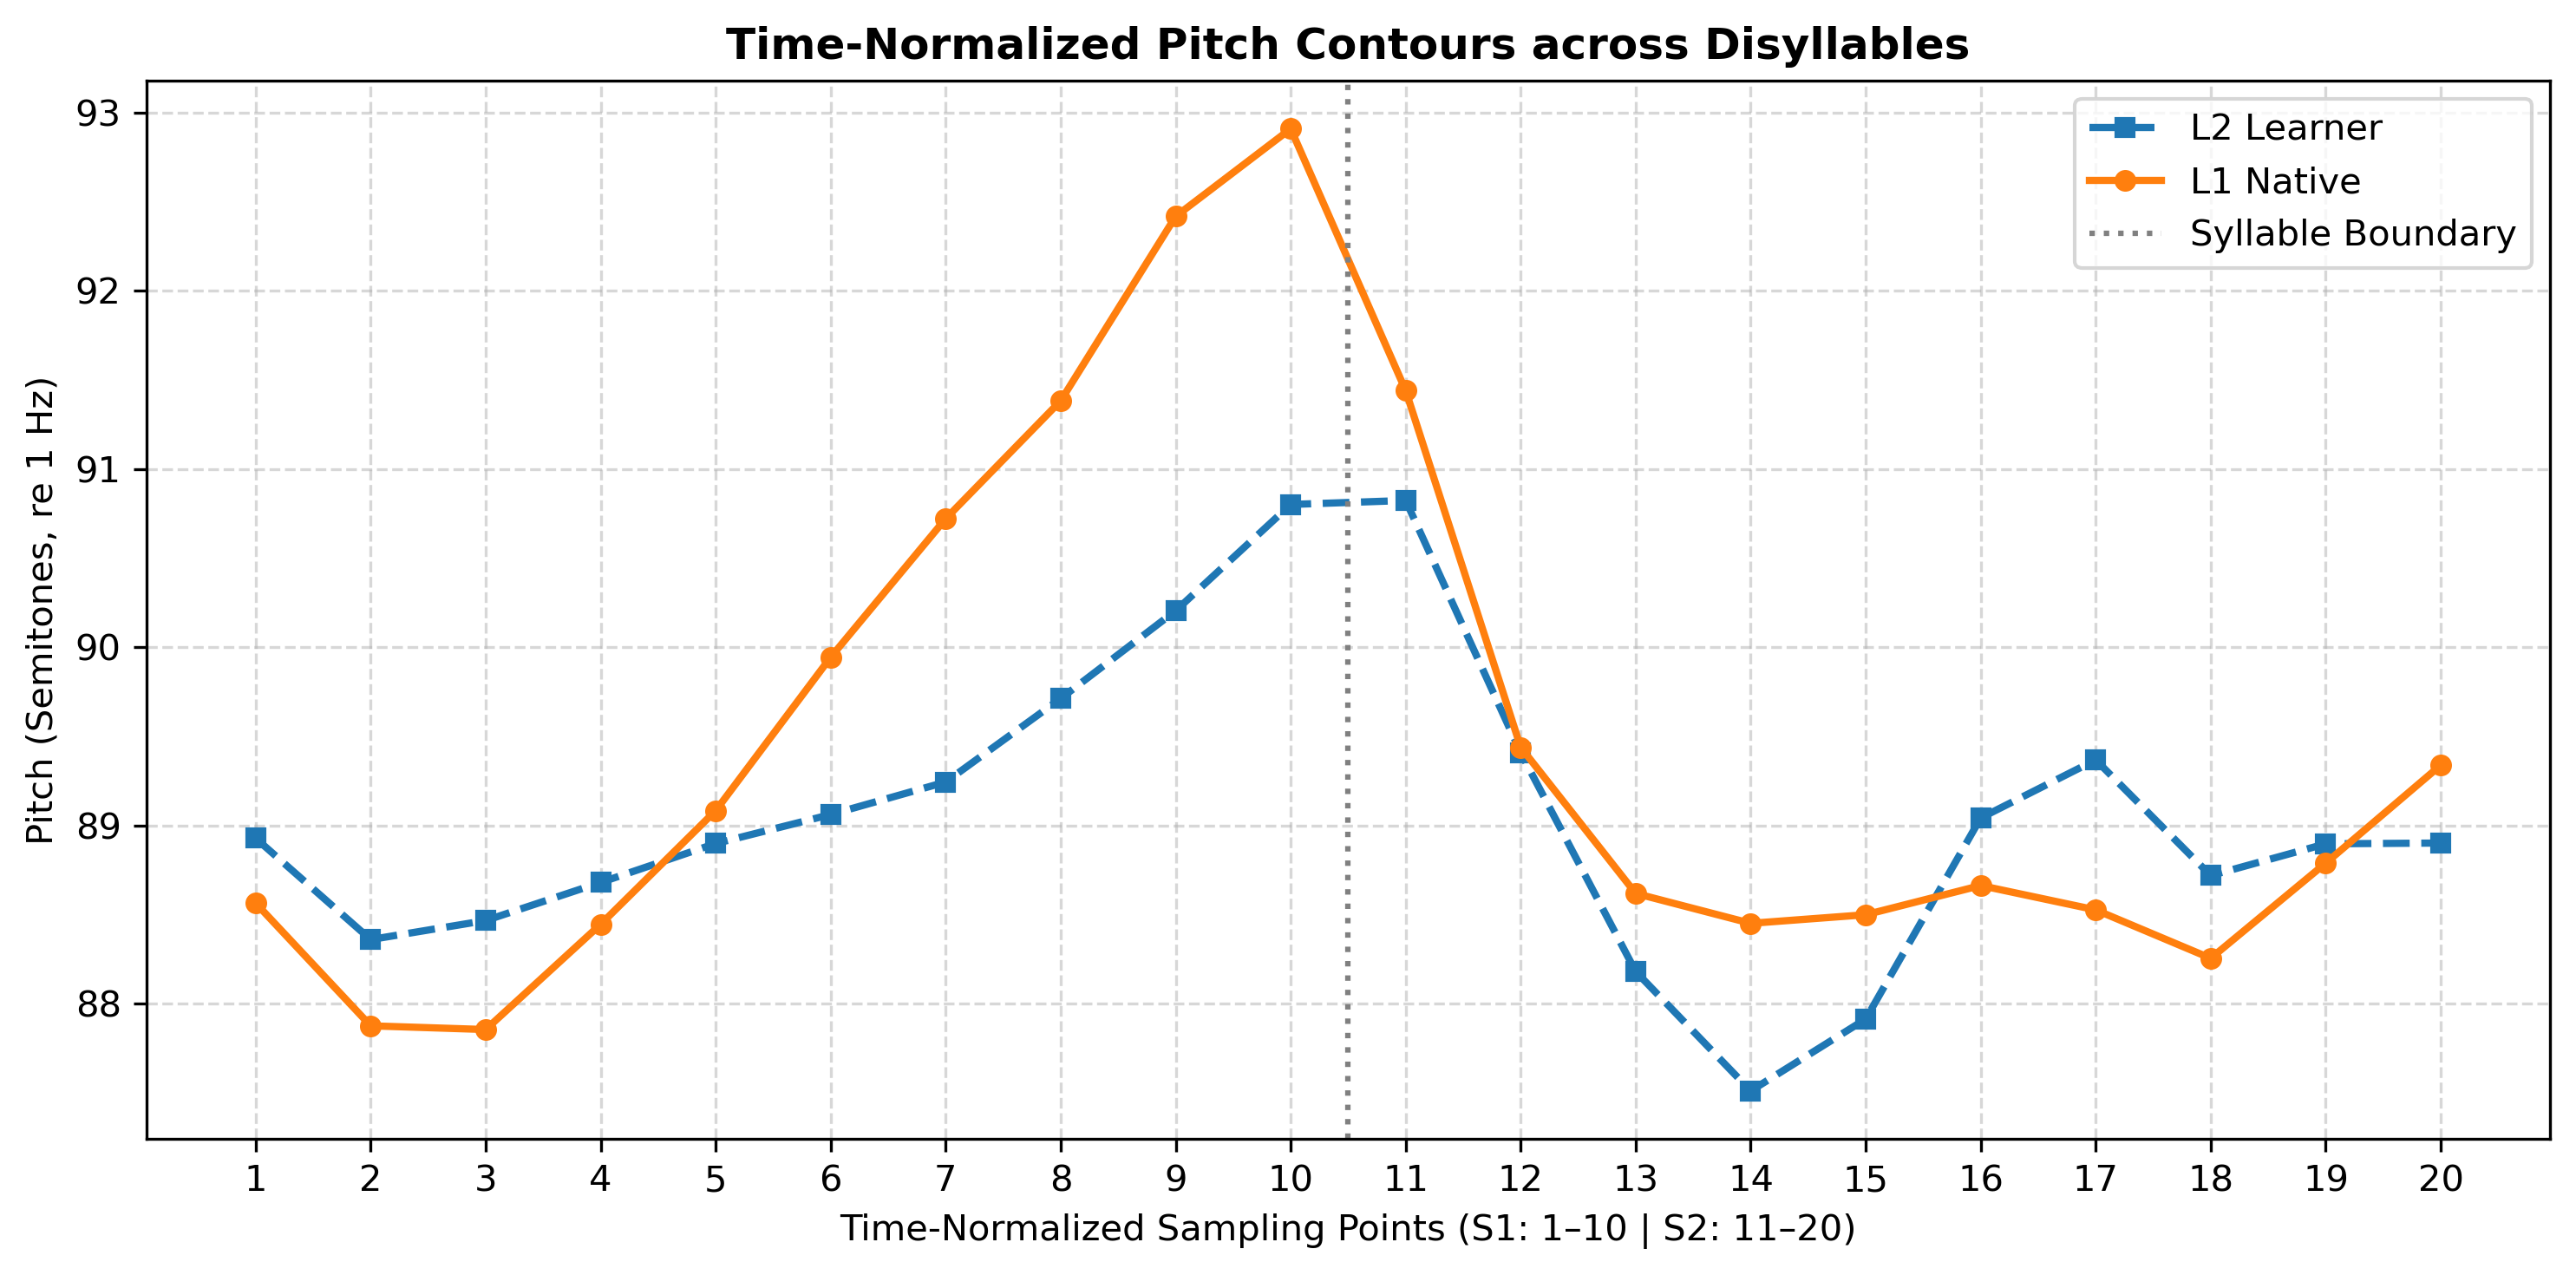

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# 读取刚导出的轨迹均值数据
df_contour = pd.read_csv("pitch_contours_summary.csv", index_col=0)

plt.figure(figsize=(10, 5), dpi=300)

# 提取 20 个点的半音数值
points = [f"Point_{i}" for i in range(1, 21)]
x_axis = range(1, 21)

for group_name in df_contour.index:
    y_values = df_contour.loc[group_name, points]
    label = "L1 Native" if "Native" in str(group_name) else "L2 Learner"
    style = 'o-' if "Native" in str(group_name) else 's--'
    plt.plot(x_axis, y_values, style, label=label, linewidth=2, markersize=5)

# 画一条虚线隔开 Syllable 1 (点 1-10) 和 Syllable 2 (点 11-20)
plt.axvline(x=10.5, color='gray', linestyle=':', label='Syllable Boundary')

plt.title("Time-Normalized Pitch Contours across Disyllables", fontsize=12, fontweight='bold')
plt.xlabel("Time-Normalized Sampling Points (S1: 1–10 | S2: 11–20)", fontsize=10)
plt.ylabel("Pitch (Semitones, re 1 Hz)", fontsize=10)
plt.xticks(range(1, 21))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [5]:
# 在刚才画图代码的最后一行 plt.show() 之前添加：
plt.savefig("Figure3_Pitch_Contours.png", dpi=300, bbox_inches='tight')
plt.savefig("Figure3_Pitch_Contours.pdf", bbox_inches='tight')  # LaTeX/PDF 论文首选矢量格式
plt.show()

<Figure size 640x480 with 0 Axes>

import pandas as pd
import matplotlib.pyplot as plt

# 1. 读取数据
df_contour = pd.read_csv("pitch_contours_summary.csv", index_col=0)

# 2. 创建画布
plt.figure(figsize=(10, 5), dpi=300)

points = [f"Point_{i}" for i in range(1, 21)]
x_axis = range(1, 21)

for group_name in df_contour.index:
    y_values = df_contour.loc[group_name, points]
    label = "L1 Native" if "Native" in str(group_name) else "L2 Learner"
    style = 'o-' if "Native" in str(group_name) else 's--'
    plt.plot(x_axis, y_values, style, label=label, linewidth=2, markersize=5)

plt.axvline(x=10.5, color='gray', linestyle=':', label='Syllable Boundary')
plt.title("Time-Normalized Pitch Contours across Disyllables", fontsize=12, fontweight='bold')
plt.xlabel("Time-Normalized Sampling Points (S1: 1–10 | S2: 11–20)", fontsize=10)
plt.ylabel("Pitch (Semitones, re 1 Hz)", fontsize=10)
plt.xticks(range(1, 21))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# ⚠️ 关键操作：必须先保存图片，再 plt.show()！
plt.savefig("Figure3_Pitch_Contours.png", dpi=300, bbox_inches='tight')
plt.savefig("Figure3_Pitch_Contours.pdf", bbox_inches='tight')

# 3. 最后展示
plt.show()

print("✅ 新的图片已成功覆写导出！请重新插入项目文件夹里的 'Figure3_Pitch_Contours.png'。")

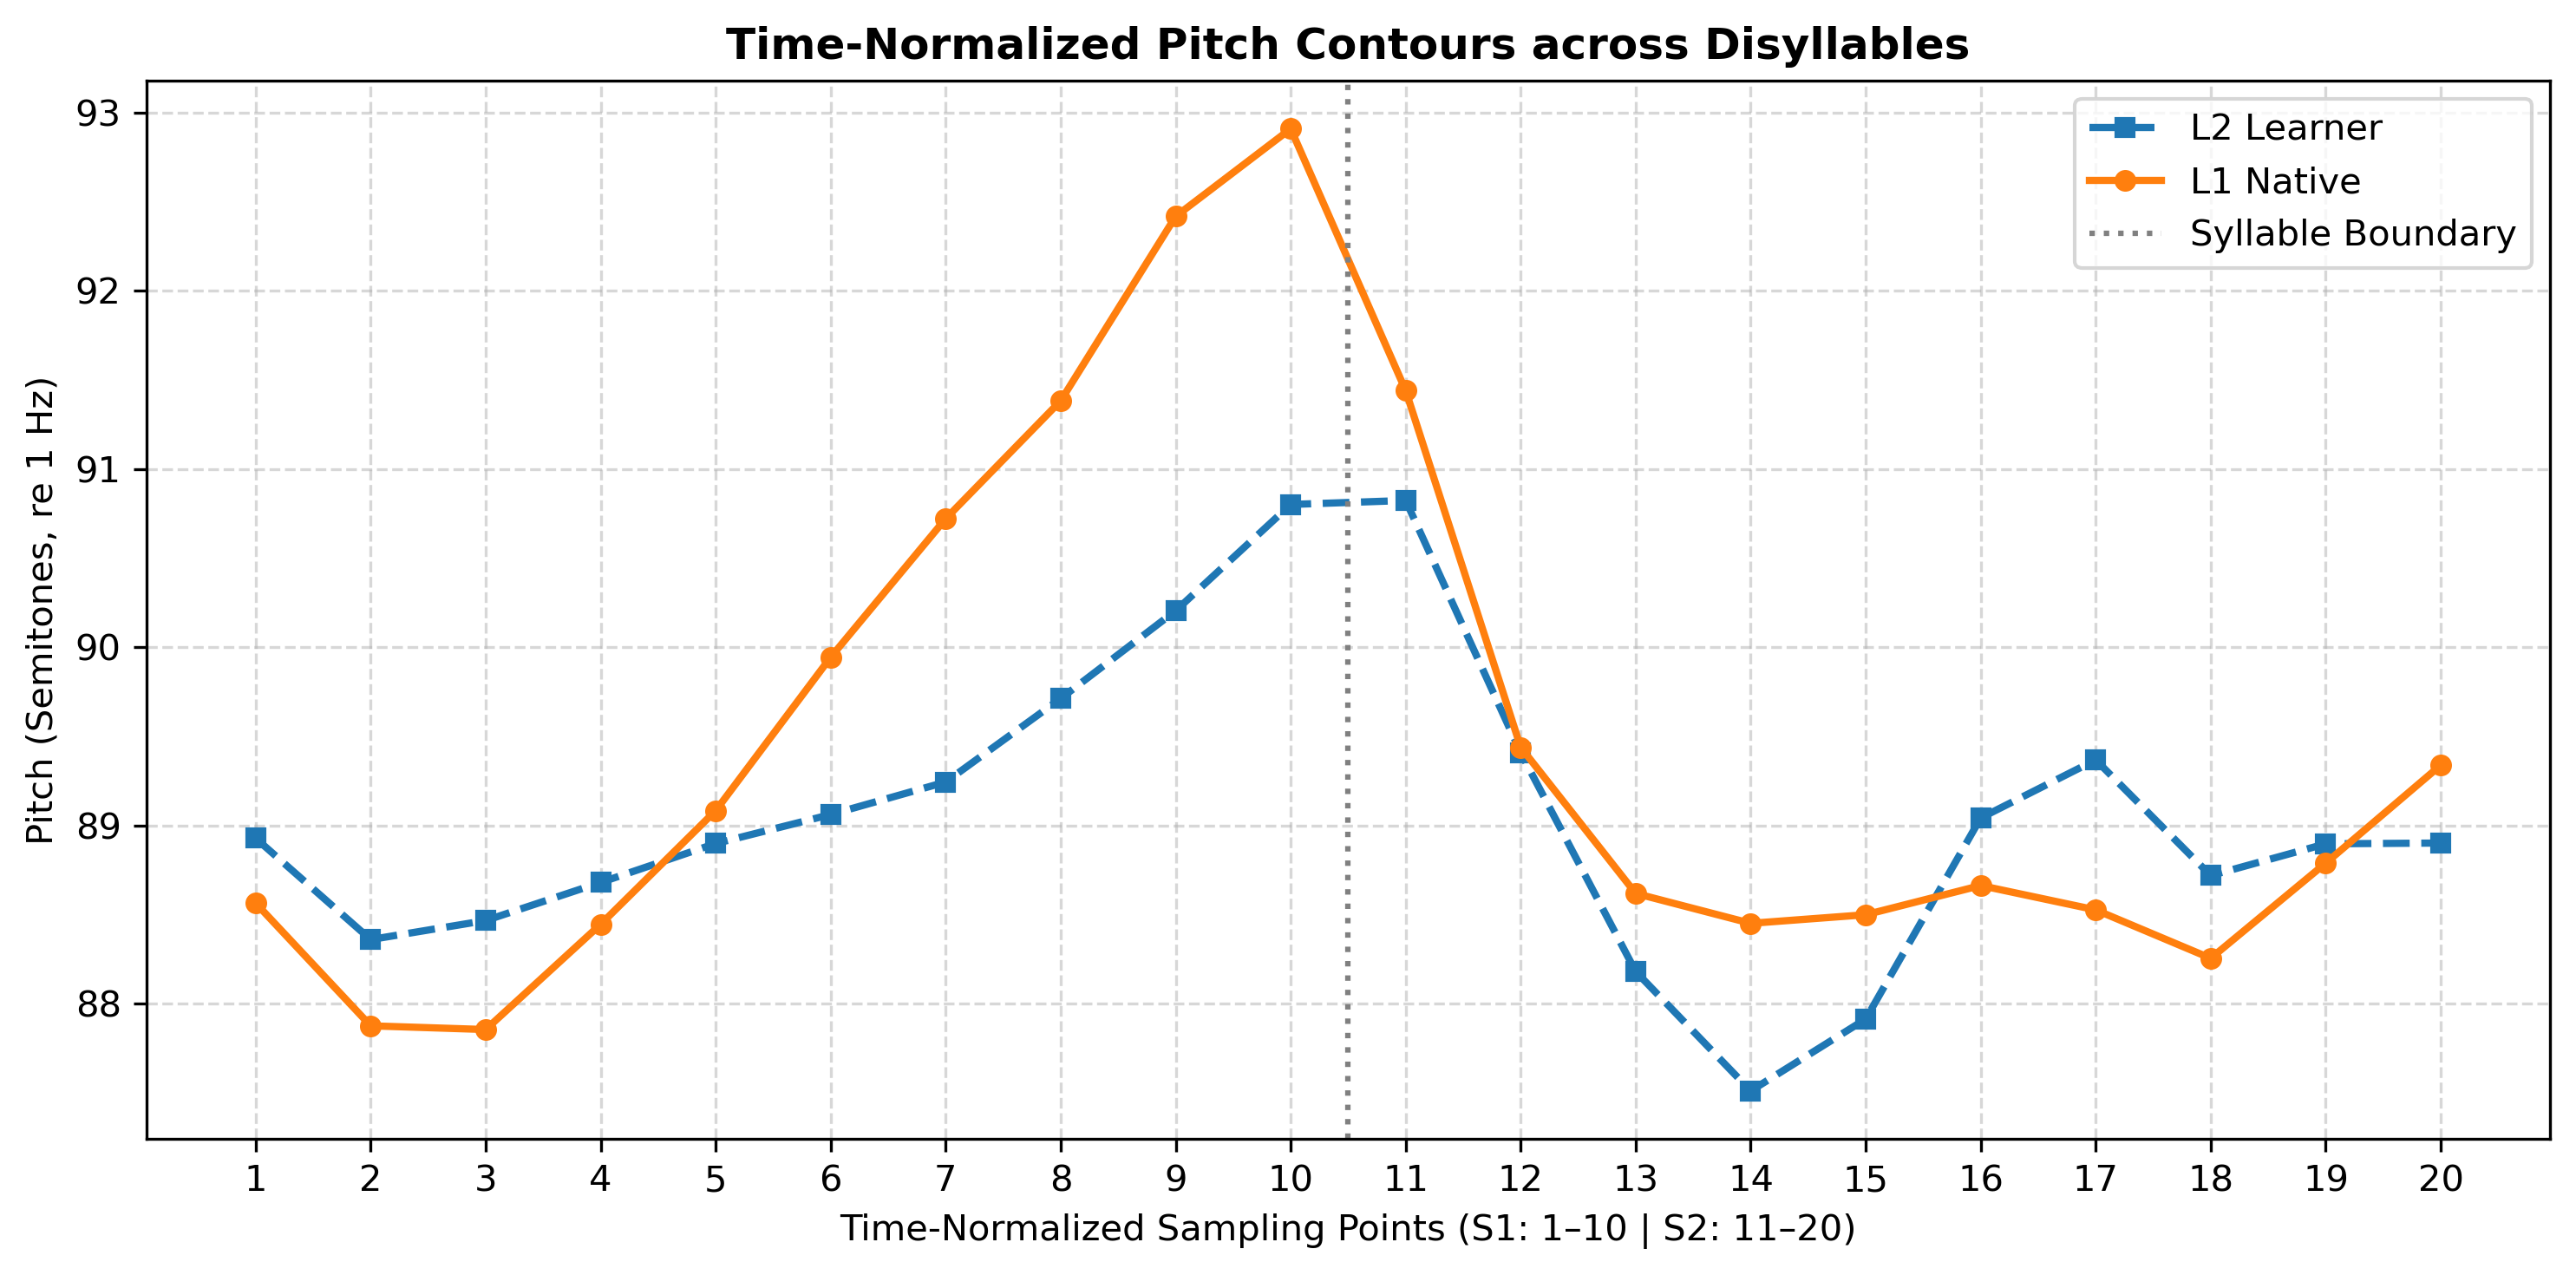

✅ 新的图片已成功覆写导出！请重新插入项目文件夹里的 'Figure3_Pitch_Contours.png'。


In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. 读取数据
df_contour = pd.read_csv("pitch_contours_summary.csv", index_col=0)

# 2. 创建画布
plt.figure(figsize=(10, 5), dpi=300)

points = [f"Point_{i}" for i in range(1, 21)]
x_axis = range(1, 21)

for group_name in df_contour.index:
    y_values = df_contour.loc[group_name, points]
    label = "L1 Native" if "Native" in str(group_name) else "L2 Learner"
    style = 'o-' if "Native" in str(group_name) else 's--'
    plt.plot(x_axis, y_values, style, label=label, linewidth=2, markersize=5)

plt.axvline(x=10.5, color='gray', linestyle=':', label='Syllable Boundary')
plt.title("Time-Normalized Pitch Contours across Disyllables", fontsize=12, fontweight='bold')
plt.xlabel("Time-Normalized Sampling Points (S1: 1–10 | S2: 11–20)", fontsize=10)
plt.ylabel("Pitch (Semitones, re 1 Hz)", fontsize=10)
plt.xticks(range(1, 21))
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# ⚠️ 关键操作：必须先保存图片，再 plt.show()！
plt.savefig("Figure3_Pitch_Contours.png", dpi=300, bbox_inches='tight')
plt.savefig("Figure3_Pitch_Contours.pdf", bbox_inches='tight')

# 3. 最后展示
plt.show()

print("✅ 新的图片已成功覆写导出！请重新插入项目文件夹里的 'Figure3_Pitch_Contours.png'。")